In [115]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [116]:
file = uproot.open("build/yz.root")

print(file.keys()) 
tree = file["yz"]
df = tree.arrays(library="pd")

['yz;1']


### STEP 1
Plottare tutte e quantità del file

In [117]:
custom_ranges = {
    'radius': None,
    'nbHits': None,
    'nbScoredHits': None,
    'y': None,
    'z': None,
    'Einc': (-0.02, 0.02),
    'Nuclear_dose': None,
    'Cytoplasmic_dose': None
}

cols_to_plot = ['radius', 'nbHits', 'nbScoredHits', 'y', 'z', 'Einc','Nuclear_dose', 'Cytoplasmic_dose']

units = {
    'radius': ' [nm]',
    'nbHits': '',
    'nbScoredHits': '',
    'y': ' [keV/um]',
    'z': ' [Gy]',
    'Einc': ' [MeV]',
    'Nuclear_dose' : '[Gy]',
    'Cytoplasmic_dose': '[Gy]'
} # Controlla se sto facendo bene...!

count = len(df)
# Senza [1:], includi TUTTI gli indici trovati
counts = df['nbScoredHits'].value_counts().sort_index()

n_zeros = (df['nbScoredHits'] == 0).sum()
print(f"Number of events with nbEdep = 0: {n_zeros}")

for i, count in counts.items():
    print(f"Number of events with nbEdep = {int(i)}: {int(count)}")

# Somma totale di tutto quello che hai trovato
print(f"Total of number of Event = {counts.sum()}")

Number of events with nbEdep = 0: 0
Number of events with nbEdep = 1: 34
Number of events with nbEdep = 2: 12
Number of events with nbEdep = 3: 22
Number of events with nbEdep = 4: 35
Number of events with nbEdep = 5: 25
Number of events with nbEdep = 6: 14
Number of events with nbEdep = 7: 28
Number of events with nbEdep = 8: 16
Number of events with nbEdep = 9: 18
Number of events with nbEdep = 10: 21
Number of events with nbEdep = 11: 24
Number of events with nbEdep = 12: 16
Number of events with nbEdep = 13: 28
Number of events with nbEdep = 14: 19
Number of events with nbEdep = 15: 10
Number of events with nbEdep = 16: 14
Number of events with nbEdep = 17: 10
Number of events with nbEdep = 18: 12
Number of events with nbEdep = 19: 4
Number of events with nbEdep = 20: 8
Number of events with nbEdep = 21: 4
Number of events with nbEdep = 22: 5
Number of events with nbEdep = 23: 12
Number of events with nbEdep = 24: 7
Number of events with nbEdep = 25: 5
Number of events with nbEdep 

 Istogramma radius ha un range impostato a: None
 Istogramma nbHits ha un range impostato a: None
 Istogramma nbScoredHits ha un range impostato a: None
 Istogramma y ha un range impostato a: None
 Istogramma z ha un range impostato a: None


 Istogramma Einc ha un range impostato a: (-0.02, 0.02)
 Istogramma Nuclear_dose ha un range impostato a: None
 Istogramma Cytoplasmic_dose ha un range impostato a: None


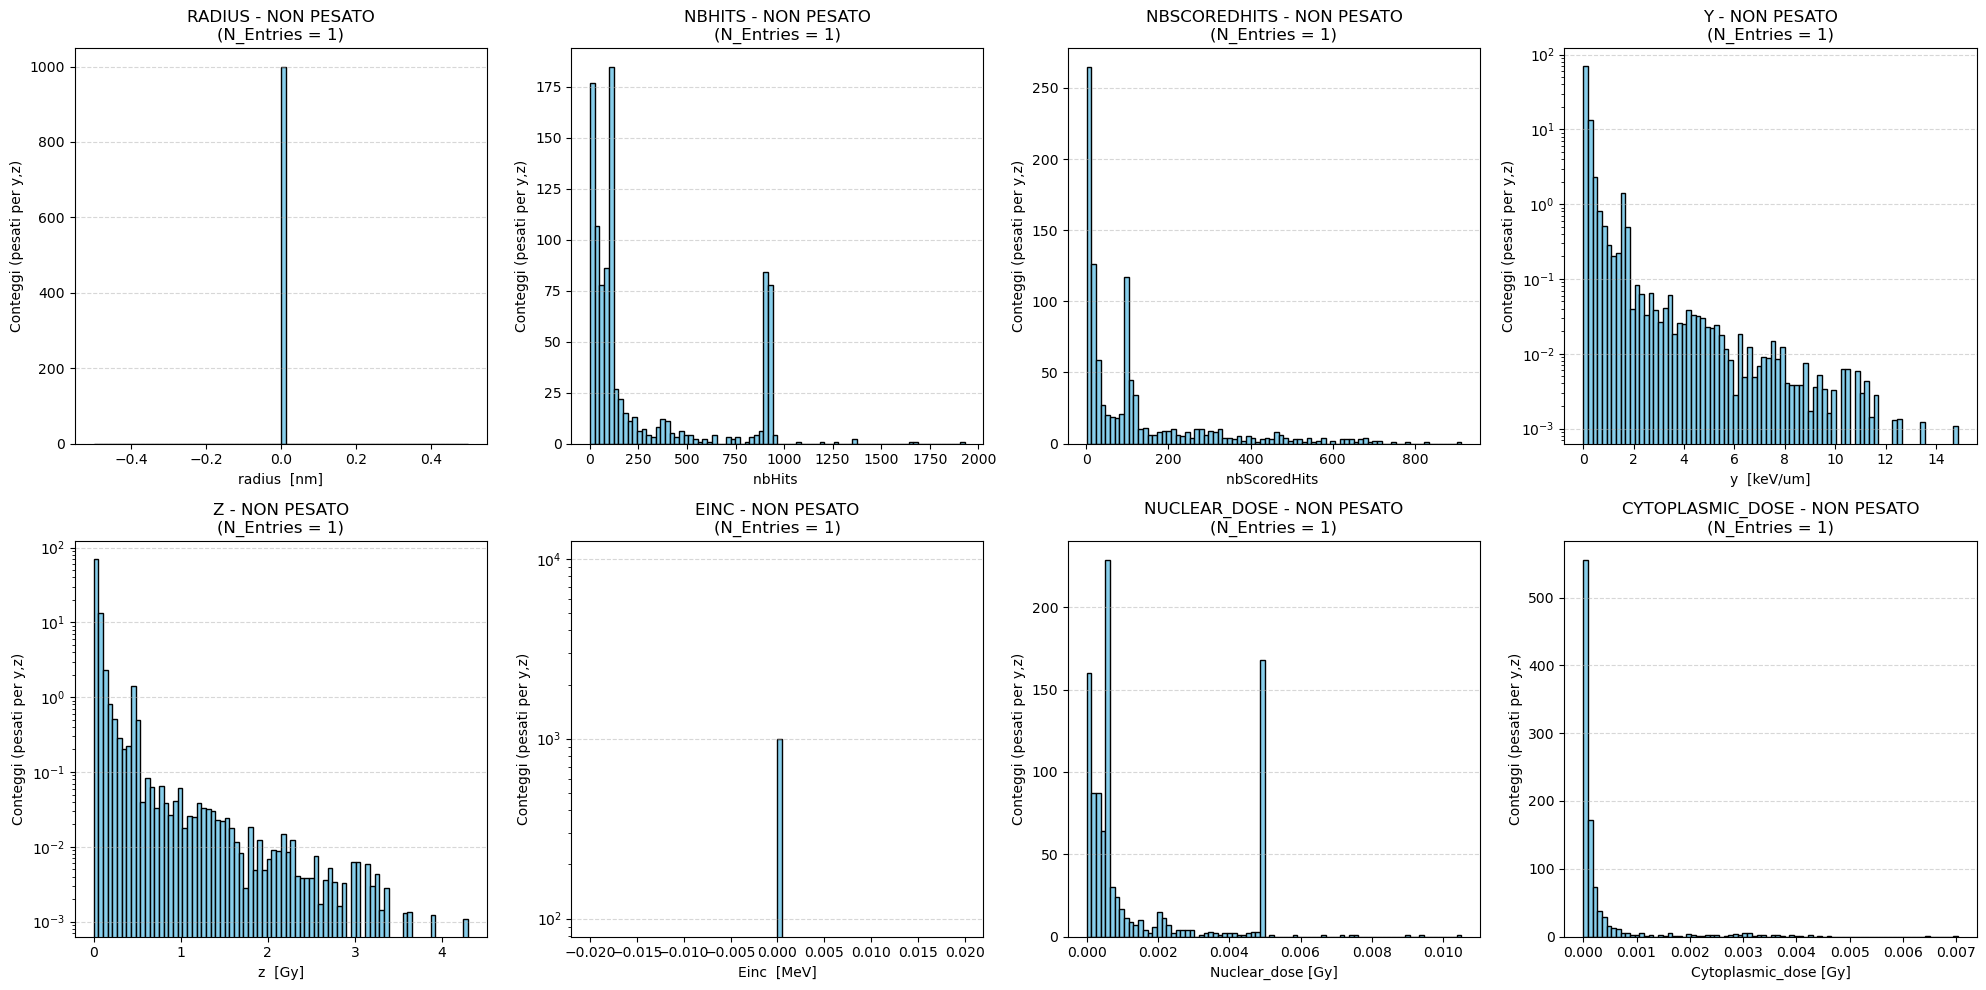

In [118]:
import matplotlib.pyplot as plt
import numpy as np

# 1. CALCOLO PESI (Una sola volta)
# Se nbScoredHits è > 0, il peso è 1/nbScoredHits, altrimenti è 0
df['weight'] = 1.0 / df['nbScoredHits']

# 2. DEFINIZIONE DELLE COLONNE E RANGE (Puoi personalizzare i range qui)
cols_to_plot = ['radius', 'nbHits', 'nbScoredHits', 'y', 'z', 'Einc', 'Nuclear_dose', 'Cytoplasmic_dose']

# 3. PLOTTING
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    current_range = custom_ranges.get(col)
    print(f" Istogramma {col} ha un range impostato a: {current_range}")
    # Applichiamo il peso SOLO se la colonna è 'y' o 'z'
    current_weights = df['weight'] if col in ['y', 'z'] else None
    
    # Decidiamo la scala logaritmica (opzionale, basato sui tuoi dati)
    is_log = col in ['y', 'z', 'Einc']
    
    # Plot dell'istogramma
    axes[i].hist(df[col], bins=80, range=custom_ranges.get(col), 
                 color='skyblue', edgecolor='black', log=is_log, 
                 weights=current_weights)
    
    axes[i].set_title(f'{col.upper()} - NON PESATO\n(N_Entries = {count})')
    axes[i].set_xlabel(f'{col} {units.get(col, "")}')
    axes[i].set_ylabel('Conteggi (pesati per y,z)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

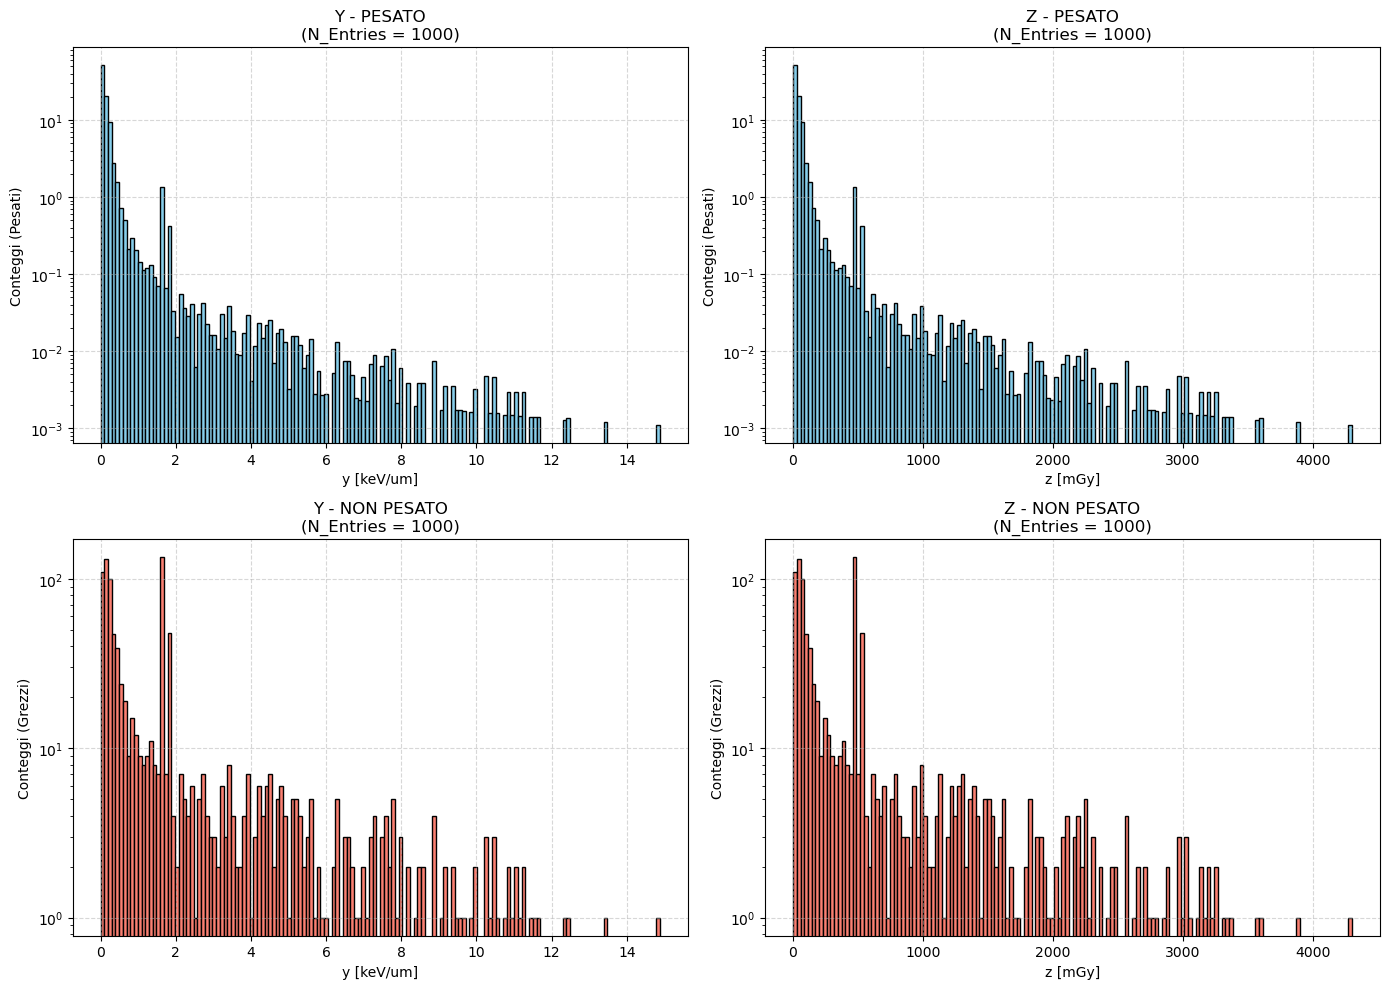

In [119]:
import matplotlib.pyplot as plt
import numpy as np

# Fattori di conversione
scales = {'y': 1.0, 'z': 1000.0}
units_label = {'y': 'keV/um', 'z': 'mGy'}

# Creiamo la figura
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# Definiamo le colonne
cols = ['y', 'z']

for i, col in enumerate(cols):
    data = df[col] * scales[col]
    
    # Calcolo conteggi
    # Per il non pesato: numero puro di eventi
    count = len(df)
    
    # 1. GRAFICO PESATO
    axes[0, i].hist(data, bins=150, range=None, weights=df['weight'], 
                    color='skyblue', edgecolor='black', log=True)
    axes[0, i].set_title(f'{col.upper()} - PESATO\n(N_Entries = {count:.0f})')
    axes[0, i].set_ylabel('Conteggi (Pesati)')
    axes[0, i].set_xlabel(f'{col} [{units_label[col]}]')
    axes[0, i].grid(linestyle='--', alpha=0.5)

    # 2. GRAFICO NON PESATO
    axes[1, i].hist(data, bins=150, range=None, weights=None, 
                    color='salmon', edgecolor='black', log=True)
    axes[1, i].set_title(f'{col.upper()} - NON PESATO\n(N_Entries = {count})')
    axes[1, i].set_ylabel('Conteggi (Grezzi)')
    axes[1, i].set_xlabel(f'{col} [{units_label[col]}]')
    axes[1, i].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [120]:
df['y'].head(), df['z'].head(), df['nbScoredHits'].head()

(0     1.622169
 1     0.007044
 2     8.363584
 3     1.536757
 4    10.457328
 Name: y, dtype: float64,
 0    0.468984
 1    0.002037
 2    2.417989
 3    0.444291
 4    3.023310
 Name: z, dtype: float64,
 0    101.0
 1      1.0
 2    515.0
 3     96.0
 4    642.0
 Name: nbScoredHits, dtype: float64)

In [121]:
# Andiamo a creare y_data e z_data che sono array di y e z originali pesati su nbScoredHits.
df_pesato = pd.DataFrame()

df_pesato['y'] = df['y'] / df['nbScoredHits']
df_pesato['z'] = df['z'] / df['nbScoredHits']

df_pesato['y'].head(), df_pesato['z'].head()


(0    0.016061
 1    0.007044
 2    0.016240
 3    0.016008
 4    0.016289
 Name: y, dtype: float64,
 0    0.004643
 1    0.002037
 2    0.004695
 3    0.004628
 4    0.004709
 Name: z, dtype: float64)

### Step 3
Intera pipeline dalle quantità microdosimetriche a MKM e LQ model.

In [122]:
R_d = 0.420       # Raggio del dominio (420 nm -> 0.420 um)
R_n = 4.0         # Raggio del nucleo cellulare (4.0 um)
y0 = 150.0        # Parametro di saturazione MKM [keV/um]
alpha_0 = 0.147   # Radiosensibilità lineare [Gy^-1]
beta_cell = 0.02  # Coefficiente quadratico [Gy^-2]

# Costante di conversione microdosimetrica sferica: passo da keV/um a Gy
k_conv = 0.12015 / (R_d*R_d)
rapporto_volumi = (R_d / R_n)**3 

In [123]:
y_f = df_pesato['y'].mean()
y_d_dose_mean = (df_pesato['y']**2).sum() / df_pesato['y'].sum()

# Calcolo di y* (energia lineare media pesata in dose satura per il MKM)
y_numerator = np.sum((y0**2) * (1 - np.exp(-(df_pesato['y']**2) / (y0**2))))
y_denominator = np.sum(df_pesato['y'])
y_star = y_numerator / y_denominator
# Calcolo dell'Alpha cellulare effettivo secondo il modello MKM
alpha_cell = alpha_0 + (beta_cell * k_conv * y_star)

print("\n--- DIAGNOSTICA PARAMETRI FISICI ---")
print(f"y_F (Frequency-mean): {y_f:.4f} keV/um")
print(f"y_D (Dose-mean):      {y_d_dose_mean:.4f} keV/um")
print(f"y* (Satura MKM):      {y_star:.4f} keV/um")
print(f"Alpha Cell (MKM):     {alpha_cell:.4f} Gy^-1")
print(f"Dose media per singolo hit (z_F): {df_pesato['z'].mean():.4f} Gy")
print("------------------------------------\n")


--- DIAGNOSTICA PARAMETRI FISICI ---
y_F (Frequency-mean): 0.0178 keV/um
y_D (Dose-mean):      0.0246 keV/um
y* (Satura MKM):      0.0246 keV/um
Alpha Cell (MKM):     0.1473 Gy^-1
Dose media per singolo hit (z_F): 0.0051 Gy
------------------------------------



In [124]:
rho = 10 ** (-15) # Densità acqua in kg/um^3
k_energetico = 1.602 * 10 **(-16) # Per passare da keV a Joule
alfa_cell = alpha_0 + (beta_cell* k_energetico *y_star)/(np.pi* rho *R_d*R_d)
D_nucleo = df['Nuclear_dose'].sum()
meno_lnS = alfa_cell*D_nucleo + beta_cell*D_nucleo*D_nucleo

In [125]:
casi_decadimenti = np.linspace(0, 20000, 100) 

risultati_sopravvivenza = []
dosi_medie_nucleo = []
rbe_lista = []

std_sopravvivenza = []
std_rbe = []

n_sim = 300
print("Numero di isotopi decaduti:\n")
for N in casi_decadimenti:
    print(f"Isotopi decaduti: {N}")
    S_temp = []
    D_temp = []
    rbe_temp = []

    for _ in range(n_sim):

        df_sample_y = df_pesato['y'].sample(int(N), replace=True)
        df_sample_Nuclear_dose = df['Nuclear_dose'].sample(int(N), replace=True)

        # y_star che dipende da N
        y_numerator = np.sum((y0**2) * (1 - np.exp(-(df_sample_y**2) / (y0**2))))
        y_denominator = np.sum(df_sample_y)
        y_star = y_numerator / y_denominator

        # Dose nucleare sommativa sul paniere in base a N
        D_nucleo = df_sample_Nuclear_dose.sum()

        alpha_cell = alpha_0 + (beta_cell* k_energetico *y_star)/(np.pi* rho *R_d*R_d)
        S = np.exp(-alpha_cell * D_nucleo - beta_cell * (D_nucleo**2))

        rbe = (np.sqrt(alpha_0**2 + 4 * beta_cell * (alpha_cell * D_nucleo + beta_cell * (D_nucleo**2))) - alpha_0) / (2 * beta_cell * D_nucleo)

        S_temp.append(S)
        D_temp.append(D_nucleo)
        rbe_temp.append(rbe)

        # Salvataggio medie e deviazioni standard
    risultati_sopravvivenza.append(np.mean(S_temp))
    dosi_medie_nucleo.append(np.mean(D_temp))
    rbe_lista.append(np.mean(rbe_temp))

    std_sopravvivenza.append(np.std(S_temp))
    std_rbe.append(np.std(rbe_temp))

Numero di isotopi decaduti:

Isotopi decaduti: 0.0
Isotopi decaduti: 202.02020202020202
Isotopi decaduti: 404.04040404040404


/tmp/ipykernel_4262/3238985608.py:26: RuntimeWarning: invalid value encountered in scalar divide
  y_star = y_numerator / y_denominator


Isotopi decaduti: 606.060606060606
Isotopi decaduti: 808.0808080808081
Isotopi decaduti: 1010.1010101010102
Isotopi decaduti: 1212.121212121212
Isotopi decaduti: 1414.141414141414
Isotopi decaduti: 1616.1616161616162
Isotopi decaduti: 1818.1818181818182
Isotopi decaduti: 2020.2020202020203
Isotopi decaduti: 2222.222222222222
Isotopi decaduti: 2424.242424242424
Isotopi decaduti: 2626.2626262626263
Isotopi decaduti: 2828.282828282828
Isotopi decaduti: 3030.3030303030305
Isotopi decaduti: 3232.3232323232323
Isotopi decaduti: 3434.343434343434
Isotopi decaduti: 3636.3636363636365
Isotopi decaduti: 3838.3838383838383
Isotopi decaduti: 4040.4040404040406
Isotopi decaduti: 4242.424242424242
Isotopi decaduti: 4444.444444444444
Isotopi decaduti: 4646.464646464647
Isotopi decaduti: 4848.484848484848
Isotopi decaduti: 5050.50505050505
Isotopi decaduti: 5252.525252525253
Isotopi decaduti: 5454.545454545455
Isotopi decaduti: 5656.565656565656
Isotopi decaduti: 5858.585858585859
Isotopi decaduti: 60

Questa parte è fatta da Gemini perché puramente grafica


       RISULTATI CLINICI ALLA SOGLIA D10
Decadimenti necessari (N_10):   5233.2 isotopi
Dose Nucleo simulata (D_10):   7.6675 Gy
Dose Riferimento (X-Ray):      7.6667 Gy
RBE effettivo al 10%:          1.000



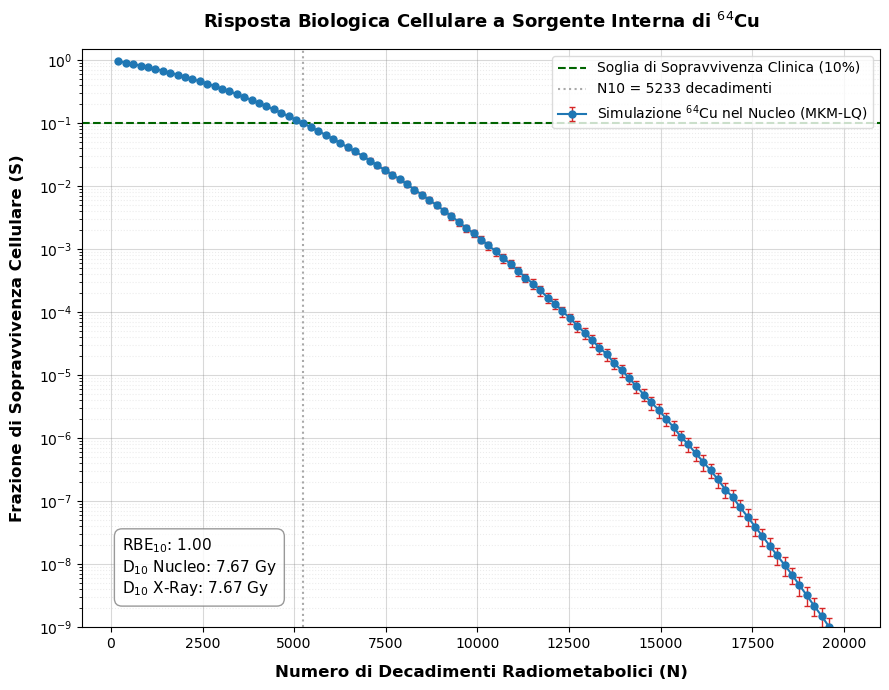

In [126]:
# =====================================================================
# BLOCCO COMPLEMENTARE DI ANALISI BIOLOGICA (D_10 ed RBE_10)
# =====================================================================

# Inversione degli array per l'interpolazione (np.interp richiede asse X crescente)
log_S_rev = np.log(np.array(risultati_sopravvivenza)[::-1])
casi_rev = casi_decadimenti[::-1]

# 1. Trova quanti decadimenti servono per arrivare alla soglia del 10% (S = 0.10)
decadimenti_soglia = np.interp(np.log(0.10), log_S_rev, casi_rev)

# 2. Trova la dose reale assorbita dal nucleo in corrispondenza di quel punto
dosi_nucleo_array = np.array(dosi_medie_nucleo)
dose_soglia_sim = np.interp(np.log(0.10), log_S_rev, dosi_nucleo_array[::-1])

# 3. Calcola la dose teorica di riferimento (X-ray a basso LET) usando la formula risolutiva LQ
dose_soglia_ref = (-alpha_0 + np.sqrt(alpha_0**2 - 4 * beta_cell * np.log(0.10))) / (2 * beta_cell)

# 4. Calcola l'RBE effettivo alla soglia terapeutica del 10%
rbe_al_10 = dose_soglia_ref / dose_soglia_sim

# Stampa diagnostica dei risultati clinici sulla console
print("\n" + "="*45)
print("       RISULTATI CLINICI ALLA SOGLIA D10")
print("="*45)
print(f"Decadimenti necessari (N_10):   {decadimenti_soglia:.1f} isotopi")
print(f"Dose Nucleo simulata (D_10):   {dose_soglia_sim:.4f} Gy")
print(f"Dose Riferimento (X-Ray):      {dose_soglia_ref:.4f} Gy")
print(f"RBE effettivo al 10%:          {rbe_al_10:.3f}")
print("="*45 + "\n")

# =====================================================================
# BLOCCO GRAFICO AVANZATO (MATPLOTLIB)
# =====================================================================
plt.figure(figsize=(9, 7), dpi=100)

# Stile del grafico principale con le tue variabili esatte
plt.errorbar(casi_decadimenti, risultati_sopravvivenza, yerr=std_sopravvivenza, 
             fmt='-o', markersize=5, color='#1f77b4', 
             ecolor='#d62728', elinewidth=1, capsize=2, capthick=1,
             label=r'Simulazione $^{64}$Cu nel Nucleo (MKM-LQ)')

# Linea orizzontale di riferimento per la soglia clinica del 10%
plt.axhline(y=0.10, color='darkgreen', linestyle='--', linewidth=1.5, 
            label='Soglia di Sopravvivenza Clinica (10%)')

# Linea verticale di corrispondenza per il numero di decadimenti di soglia
plt.axvline(x=decadimenti_soglia, color='darkgray', linestyle=':', linewidth=1.5,
            label=f'N10 = {int(decadimenti_soglia)} decadimenti')

# Formattazione della scala logaritmica
plt.yscale('log')
plt.ylim(1e-9, 1.5)

# Etichette e titoli
plt.xlabel('Numero di Decadimenti Radiometabolici (N)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Frazione di Sopravvivenza Cellulare (S)', fontsize=12, fontweight='bold', labelpad=10)
plt.title(r'Risposta Biologica Cellulare a Sorgente Interna di $^{64}$Cu', fontsize=13, fontweight='bold', pad=15)

# Box informativo interno
testo_box = (f"RBE$_{{10}}$: {rbe_al_10:.2f}\n"
             f"D$_{{10}}$ Nucleo: {dose_soglia_sim:.2f} Gy\n"
             f"D$_{{10}}$ X-Ray: {dose_soglia_ref:.2f} Gy")
plt.text(0.05, 0.05, testo_box, transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

# Griglia
plt.grid(True, which="major", color='gray', linestyle='-', alpha=0.3)
plt.grid(True, which="minor", color='gray', linestyle=':', alpha=0.15)

plt.legend(loc='upper right', fontsize=10, frameon=True, facecolor='white', edgecolor='lightgray')
plt.tight_layout()
plt.show()

Qui vado solo a "migliorare" la visibilità del plot.

In [134]:
print(len(df_pesato['y']))

1000


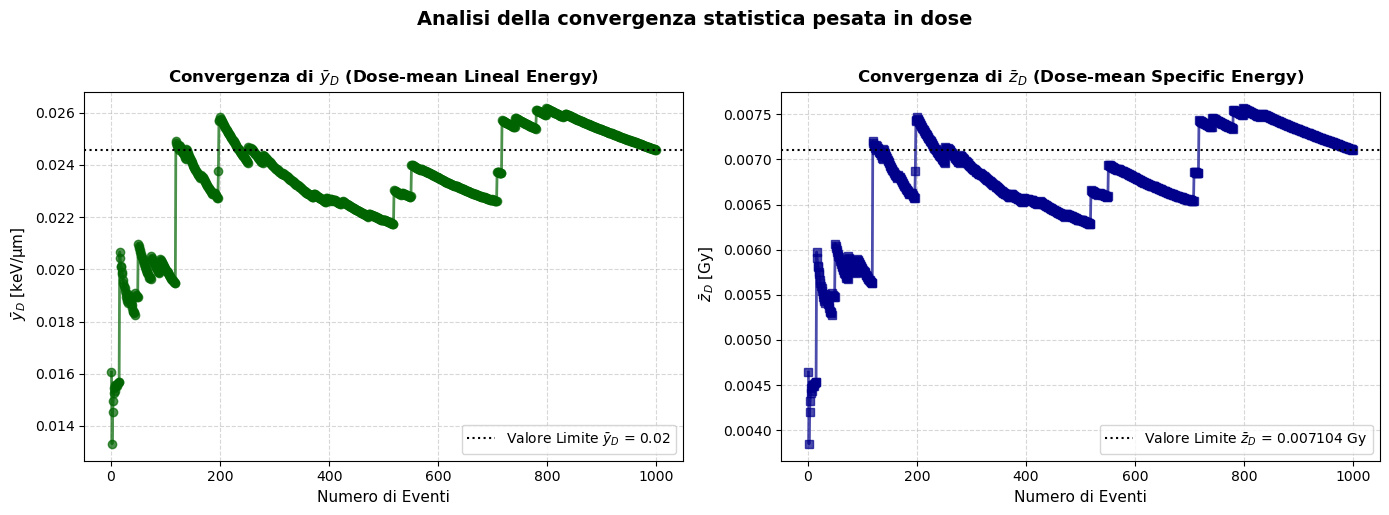

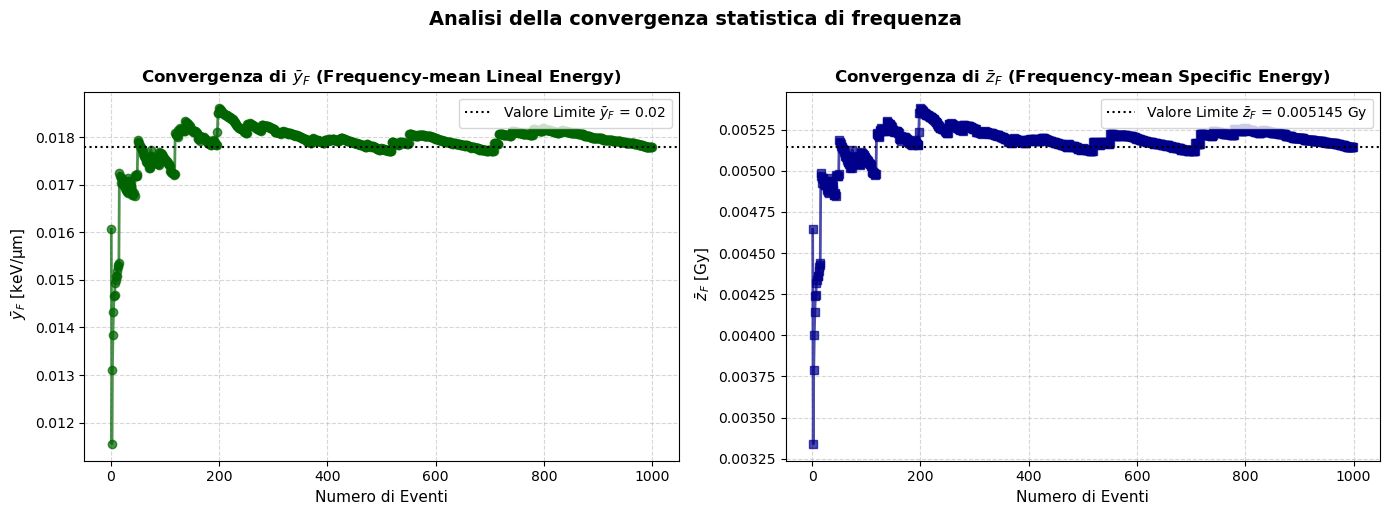

In [133]:
# ==============================================================================
# STUDIO DELLA CONVERGENZA STATISTICA DI y_D E z_D (PESATI IN DOSE)
# ==============================================================================
# Partiamo da un numero minimo di eventi (es. 'step') per evitare divisioni per zero all'inizio
step = 1
step_statistica = np.arange(step, len(df_pesato['y']), step) 

y_f_cumulativi = []
z_f_cumulativi = []

y_d_cumulativi = []
z_d_cumulativi = []

# Calcoliamo i valori "di riferimento" (limiti) sull'intero dataset per le linee orizzontali
#y_f e z_f
ref_y_f = np.mean(df_pesato['y'])
ref_z_f = np.mean(df_pesato['z'])
#y_d e z_d
ref_y_d = np.sum(df_pesato['y']**2) / np.sum(df_pesato['y'])
ref_z_d = np.sum(df_pesato['z']**2) / np.sum(df_pesato['z'])

for n_eventi in step_statistica:
    # Estraiamo i sottogruppi
    y_sub = df_pesato['y'][:n_eventi]
    z_sub = df_pesato['z'][:n_eventi]
    
    # Calcolo della media pesata in dose (Dose-mean)
    # Formula: sum(x^2) / sum(x)
    y_f_cumulativi.append(np.mean(y_sub))
    z_f_cumulativi.append(np.mean(z_sub))
    y_d_cumulativi.append(np.sum(y_sub**2) / np.sum(y_sub))
    z_d_cumulativi.append(np.sum(z_sub**2) / np.sum(z_sub))

# Convertiamo in array
y_f_cumulativi = np.array(y_f_cumulativi)
z_f_cumulativi = np.array(z_f_cumulativi)

y_d_cumulativi = np.array(y_d_cumulativi)
z_d_cumulativi = np.array(z_d_cumulativi)

# --- GENERAZIONE DEL GRAFICO DI CONVERGENZA PESATA ---
fig, (ax_y, ax_z) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot per y_D
ax_y.plot(step_statistica, y_d_cumulativi, marker='o', color='darkgreen', linewidth=2, linestyle='-', alpha=0.7)
ax_y.axhline(y=ref_y_d, color='black', linestyle=':', label=f'Valore Limite $\\bar{{y}}_D$ = {ref_y_d:.2f}')
ax_y.set_xlabel("Numero di Eventi", fontsize=11)
ax_y.set_ylabel(r" $\bar{y}_D$ [keV/µm]", fontsize=11)
ax_y.set_title(r"Convergenza di $\bar{y}_D$ (Dose-mean Lineal Energy)", fontsize=12, fontweight='bold')
ax_y.grid(True, linestyle='--', alpha=0.5)
ax_y.legend()

# 2. Plot per z_D
ax_z.plot(step_statistica, z_d_cumulativi, marker='s', color='darkblue', linewidth=2, linestyle='-', alpha=0.7)
ax_z.axhline(y=ref_z_d, color='black', linestyle=':', label=f'Valore Limite $\\bar{{z}}_D$ = {ref_z_d:.6f} Gy')
ax_z.set_xlabel("Numero di Eventi", fontsize=11)
ax_z.set_ylabel(r" $\bar{z}_D$ [Gy]", fontsize=11)
ax_z.set_title(r"Convergenza di $\bar{z}_D$ (Dose-mean Specific Energy)", fontsize=12, fontweight='bold')
ax_z.grid(True, linestyle='--', alpha=0.5)
ax_z.legend()

plt.suptitle("Analisi della convergenza statistica pesata in dose", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- GENERAZIONE DEL GRAFICO DI CONVERGENZA NON PESATA ---
fig, (ax_y, ax_z) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot per y_F
ax_y.plot(step_statistica, y_f_cumulativi, marker='o', color='darkgreen', linewidth=2, linestyle='-', alpha=0.7)
ax_y.axhline(y=ref_y_f, color='black', linestyle=':', label=f'Valore Limite $\\bar{{y}}_F$ = {ref_y_f:.2f}')
ax_y.set_xlabel("Numero di Eventi", fontsize=11)
ax_y.set_ylabel(r" $\bar{y}_F$ [keV/µm]", fontsize=11)
ax_y.set_title(r"Convergenza di $\bar{y}_F$ (Frequency-mean Lineal Energy)", fontsize=12, fontweight='bold')
ax_y.grid(True, linestyle='--', alpha=0.5)
ax_y.legend()

# 2. Plot per z_F
ax_z.plot(step_statistica, z_f_cumulativi, marker='s', color='darkblue', linewidth=2, linestyle='-', alpha=0.7)
ax_z.axhline(y=ref_z_f, color='black', linestyle=':', label=f'Valore Limite $\\bar{{z}}_F$ = {ref_z_f:.6f} Gy')
ax_z.set_xlabel("Numero di Eventi", fontsize=11)
ax_z.set_ylabel(r" $\bar{z}_F$ [Gy]", fontsize=11)
ax_z.set_title(r"Convergenza di $\bar{z}_F$ (Frequency-mean Specific Energy)", fontsize=12, fontweight='bold')
ax_z.grid(True, linestyle='--', alpha=0.5)
ax_z.legend()

plt.suptitle("Analisi della convergenza statistica di frequenza", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
